# Emotions and paintings from dream description

## Classifying emotions from dream drescription

### __Model trained on GoEmotions (Dataset from Google)__

__What emotions are we talking about ?__

admiration, amusement, anger, annoyance, approval, caring, 
confusion, curiosity, desire, disappointment, disapproval, 
disgust, embarrassment, excitement, fear, gratitude, grief, 
joy, love, nervousness, optimism, pride, realization, relief, 
remorse, sadness, surprise + neutral

In [1]:
# Imports
from transformers import pipeline
import pandas as pd

In [2]:
# Initializing model
emotion_classifier_go = pipeline(
    'text-classification',
    model='SamLowe/roberta-base-go_emotions',
    top_k=4
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# Trying it out

response = emotion_classifier_go("I watched him go with a sinking feeling in my stomach")
pd.DataFrame(response[0])

,label,score
0,sadness,0.585110
1,disappointment,0.106088
2,nervousness,0.099693
3,fear,0.080609


### __Alternative model__

__What emotions are we talking about ?__

anger 🤬, disgust 🤢, fear 😨, joy 😀, neutral 😐, sadness 😭, surprise 😲


In [4]:
# Initializing model

emotion_classifier_simple = pipeline("text-classification",
                      model="j-hartmann/emotion-english-distilroberta-base",
                      top_k=4)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# Trying it out

response = emotion_classifier_simple("Wow, this is really beautiful")
pd.DataFrame(response[0])

,label,score
0,surprise,0.960435
1,joy,0.019467
2,neutral,0.008130
3,fear,0.004241


# Tagging abstract paintings

## __With CLIP__

__Imports__

In [6]:
import clip
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

__Load model__

In [7]:
#load model
model, preprocess = clip.load("ViT-B/32")

__Define and embed textual anchors for emotions__

In [8]:
# define textual descriptions of emotions
anchors = [
    'a dark and threatening abstract painting evoking fear', 
    'a violent and intense abstract painting evoking anger', 
    'a bright and vibrant abstract painting evoking joy', 
    'a melancholic and subdued abstract painting evoking sadness'
]

# then tokenize the text
tokens = clip.tokenize(anchors)

In [9]:
# embed each anchor (4 emotions) as 512-dimensional vectors 
# torch.no_grad() -> Deactivate gradient calculation since we are not training the model 
with torch.no_grad():
    text_embeddings = model.encode_text(tokens)

text_embeddings = text_embeddings.numpy()
text_embeddings

# now we have 4 vectors representing our anchors in a 512-dimensional space

array([[ 0.2804118 , -0.20871994,  0.02050669, ...,  0.4613851 ,
         0.11710248,  0.2251344 ],
       [ 0.3531309 ,  0.00456815,  0.02115739, ...,  0.30395064,
         0.28356412,  0.08645859],
       [ 0.36285076, -0.0964449 ,  0.04711551, ...,  0.04154396,
         0.20040263,  0.3805137 ],
       [ 0.22270784,  0.05962328, -0.18458849, ...,  0.153353  ,
         0.34610638,  0.16841033]], shape=(4, 512), dtype=float32)

__Embed a painting__

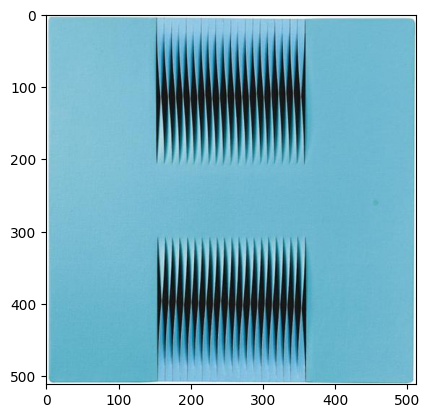

In [21]:
# chosen image 
#image_url = '/Users/lesfabs/Downloads/abstract_art_512/abstract_willem-de-kooning_3276.jpg'
#image_url = '/Users/lesfabs/Downloads/abstract_art_512/abstract_walter-leblanc_7494.jpg'
image_url = '/Users/lesfabs/Downloads/abstract_art_512/abstract_walter-leblanc_7490.jpg'
#image_url = '/Users/lesfabs/Downloads/abstract_art_512/abstract_theo-van-doesburg_3703.jpg'

img = Image.open(image_url)

plt.imshow(img)

In [22]:
# encode a painting 
# first preprocess it (reshape and normalize)
image = preprocess(Image.open(image_url)).expand(1, 3, 224, 224)
image.shape

torch.Size([1, 3, 224, 224])

In [23]:
with torch.no_grad():
    image_embedding = model.encode_image(image)

image_embedding = image_embedding.numpy()
image_embedding.shape

(1, 512)

__Calculate similarity between painting and anchors__

In [24]:
# normalize

def normalize(array):
    norms = np.linalg.norm(array, axis=1, keepdims=True)
    return array/norms

image_normalized = normalize(image_embedding)
text_normalized = normalize(text_embeddings)

# compute cosine similarity between image vector and text vector
scores = (image_normalized @ text_normalized.T).squeeze()

In [25]:
emotions = ['fear', 'anger', 'joy', 'sadness']
painting_tags = dict(zip(emotions, scores))
sorted_painting_tags = {k: v for k, v in sorted(painting_tags.items(), key=lambda item: item[1], reverse=True)}
sorted_painting_tags

{'anger': np.float32(0.24401751),
 'fear': np.float32(0.24134237),
 'sadness': np.float32(0.24102798),
 'joy': np.float32(0.23240812)}